# Used Car Price Prediction

Predicts the resale price of a used car from its brand, model, manufacturing year,
kilometers driven, and fuel type, using listing data scraped from Quikr.com.

**Steps:** data cleaning → EDA → model comparison (Linear Regression vs Random Forest) → final model

**Result:** Linear Regression, R² = 0.59, MAE ≈ ₹143,000 on held-out test data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("quikr_car.csv")
df.head(10)

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
5,Ford EcoSport Titanium 1.5L TDCi,Ford,2015,Ask For Price,"59,000 kms",Diesel
6,Ford Figo,Ford,2012,"1,75,000","41,000 kms",Diesel
7,Hyundai Eon,Hyundai,2013,"1,90,000","25,000 kms",Petrol
8,Ford EcoSport Ambiente 1.5L TDCi,Ford,2016,"8,30,000","24,530 kms",Diesel
9,Maruti Suzuki Alto K10 VXi AMT,Maruti,2015,"2,50,000","60,000 kms",Petrol


In [6]:
print(df.shape)
df.info()

(892, 6)
<class 'pandas.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        892 non-null    str  
 1   company     892 non-null    str  
 2   year        892 non-null    str  
 3   Price       892 non-null    str  
 4   kms_driven  840 non-null    str  
 5   fuel_type   837 non-null    str  
dtypes: str(6)
memory usage: 92.3 KB


In [7]:
df.isnull().sum()


name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

In [8]:
df['year'].unique()

<ArrowStringArray>
['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016', '2010',
 '2017', '2008', '2011', '2019', '2009', '2005', '2000',  '...', '150k',
 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs', 'sale', '1995', 'ara)',
 '2002', 'SELL', '2001', 'tion', 'odel', '2 bs', 'arry',  'Eon', 'o...',
 'ture',  'emi',  'car', 'able',  'no.', 'd...', 'SALE', 'digo', 'sell',
 'd Ex', 'n...', 'e...', 'D...', ', Ac', 'go .', 'k...', 'o c4', 'zire',
 'cent', 'Sumo',  'cab', 't xe',  'EV2', 'r...', 'zest']
Length: 61, dtype: str

In [10]:
df['Price'].unique()

<ArrowStringArray>
[       '80,000',      '4,25,000', 'Ask For Price',      '3,25,000',
      '5,75,000',      '1,75,000',      '1,90,000',      '8,30,000',
      '2,50,000',      '1,82,000',
 ...
        '42,000',      '1,89,000',      '1,62,000',        '35,999',
     '29,00,000',        '39,999',        '50,500',      '5,10,000',
      '8,60,000',      '5,00,001']
Length: 274, dtype: str

In [11]:
df = df[df['year'].str.isnumeric()]
df['year'] = df['year'].astype(int)

In [12]:
df['year'].unique()

array([2007, 2006, 2018, 2014, 2015, 2012, 2013, 2016, 2010, 2017, 2008,
       2011, 2019, 2009, 2005, 2000, 2003, 2004, 1995, 2002, 2001])

In [13]:
df = df[df['Price'] != 'Ask For Price']
df['Price'] = df['Price'].str.replace(',', '', regex=False).astype(int)

In [14]:
df['Price'].describe()

count    8.190000e+02
mean     4.109604e+05
std      4.744866e+05
min      3.000000e+04
25%      1.750000e+05
50%      2.999990e+05
75%      4.900000e+05
max      8.500003e+06
Name: Price, dtype: float64

In [15]:
df = df[df['kms_driven'].str.contains('kms', na=False)]
df['kms_driven'] = df['kms_driven'].str.replace(',', '', regex=False).str.replace(' kms', '', regex=False)
df['kms_driven'] = df['kms_driven'].astype(int)

In [16]:
df['kms_driven'].describe()

count       817.000000
mean      46250.714810
std       34283.745254
min           0.000000
25%       27000.000000
50%       41000.000000
75%       56758.000000
max      400000.000000
Name: kms_driven, dtype: float64

In [17]:
df = df[~df['fuel_type'].isnull()]
df['fuel_type'].value_counts()

fuel_type
Petrol    428
Diesel    386
LPG         2
Name: count, dtype: int64

In [18]:
df['name'] = df['name'].str.split(' ').str.slice(0, 3).str.join(' ')
df['name'].head(10)

0        Hyundai Santro Xing
1        Mahindra Jeep CL550
3          Hyundai Grand i10
4     Ford EcoSport Titanium
6                  Ford Figo
7                Hyundai Eon
8     Ford EcoSport Ambiente
9         Maruti Suzuki Alto
10       Skoda Fabia Classic
11    Maruti Suzuki Stingray
Name: name, dtype: object

In [19]:
df[df['Price'] > 6000000]

,name,company,year,Price,kms_driven,fuel_type
562,Mahindra XUV500 W6,Mahindra,2014,8500003,45000,Diesel


In [20]:
df.duplicated().sum()

np.int64(96)

In [21]:
df = df[df['Price'] < 6000000]
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(719, 6)


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel


In [22]:
df.to_csv("cleaned_car_data.csv", index=False)

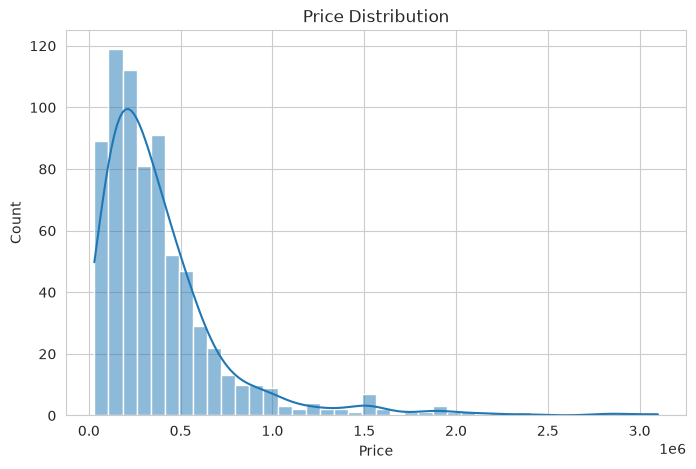

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=40, kde=True)
plt.title("Price Distribution")
plt.show()

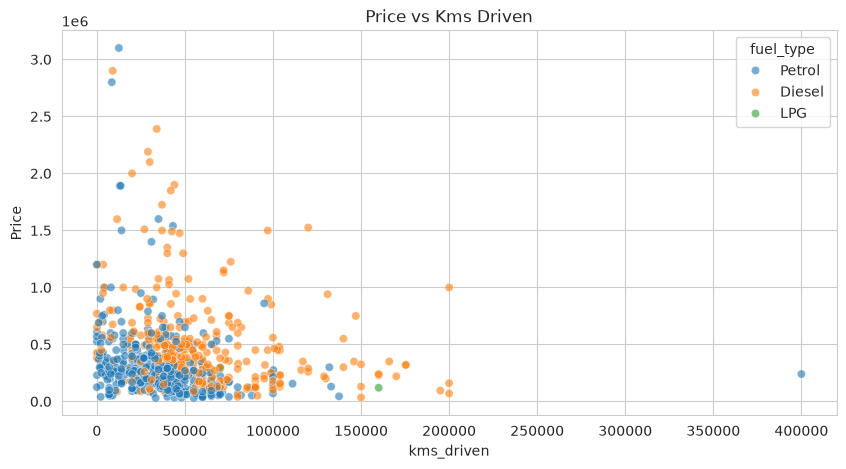

In [24]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='kms_driven', y='Price', hue='fuel_type', alpha=0.6)
plt.title("Price vs Kms Driven")
plt.show()

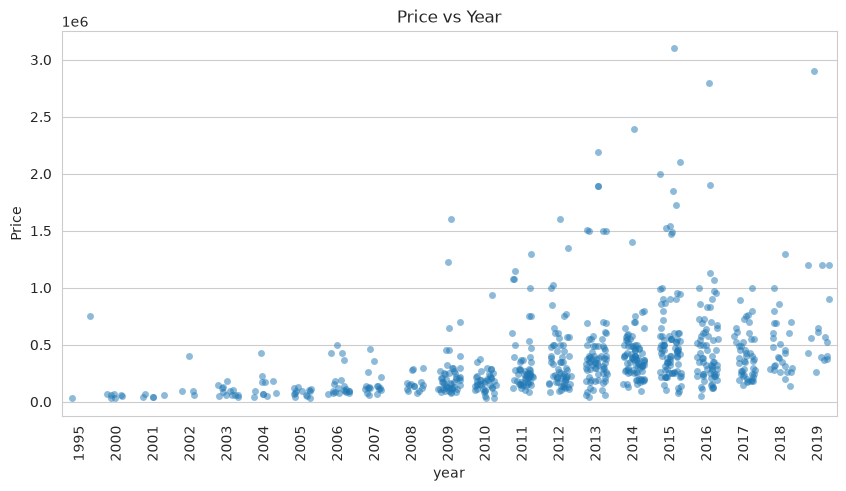

In [25]:
plt.figure(figsize=(10,5))
sns.stripplot(data=df, x='year', y='Price', alpha=0.5, jitter=0.3)
plt.xticks(rotation=90)
plt.title("Price vs Year")
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = df[['name', 'company', 'year', 'kms_driven', 'fuel_type']]
y = df['Price']

categorical_features = ['name', 'company', 'fuel_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(575, 5) (144, 5)


In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(name)
    print("  R2:", round(r2_score(y_test, y_pred), 4))
    print("  MAE:", round(mean_absolute_error(y_test, y_pred), 0))
    print("  RMSE:", round(mean_squared_error(y_test, y_pred) ** 0.5, 0))

Linear Regression
  R2: 0.5945
  MAE: 143175.0
  RMSE: 254012.0
Random Forest
  R2: 0.5628
  MAE: 132426.0
  RMSE: 263742.0


In [28]:
import pickle

final_model = Pipeline(steps=[('preprocessor', preprocessor), ('model', LinearRegression())])
final_model.fit(X_train, y_train)

with open("car_price_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Saved.")

Saved.


In [29]:
sample = pd.DataFrame([{
    "name": "Maruti Suzuki Swift",
    "company": "Maruti",
    "year": 2017,
    "kms_driven": 30000,
    "fuel_type": "Petrol"
}])

predicted_price = final_model.predict(sample)[0]
print(f"Predicted price: ₹{predicted_price:,.0f}")

Predicted price: ₹366,856


In [ ]:
y_pred = final_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Price")
plt.legend()
plt.show()

